# Automated Review Rating System

In [3]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set()
%matplotlib inline

from sklearn.model_selection import train_test_split

In [4]:
# Loading The Dataset
df = pd.read_csv('Reviews.csv')

In [5]:
# Viewing The first 5 rows
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df.shape

(568454, 10)

In [7]:
df.duplicated().sum()

0

In [8]:
#Checking the dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


# EDA

# Data Preprocessing

In [11]:
final_dataset = df[df.HelpfulnessDenominator <= df.HelpfulnessDenominator]

In [12]:
# Checking Missing Values
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [13]:
# Handling The Missing Values
df['ProfileName'] = df['ProfileName'].fillna(df['ProfileName'].mode()[0])
df['Summary'] = df['Summary'].fillna(df['Summary'].mode()[0])

In [14]:
# Text Preprocessing
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rashe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
from tqdm import tqdm
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
preprocessed_review = []

for sentence in tqdm(final_dataset['Text'].values):
    sentence = re.sub(r"http\S+", "", sentence)
    sentence = BeautifulSoup(sentence, 'lxml').get_text()
    sentence = re.sub('[^a-zA-Z]+', ' ', sentence)
    sentence = ' '.join(
        e.lower() for e in sentence.split()
        if e.lower() not in stop_words
    )
    preprocessed_review.append(sentence.strip())


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 568454/568454 [04:58<00:00, 1907.50it/s]


In [16]:
preprocessed_review

['bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better',
 'product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent product jumbo',
 'confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberally coated powdered sugar tiny mouthful heaven chewy flavorful highly recommend yummy treat familiar story c lewis lion witch wardrobe treat seduces edmund selling brother sisters witch',
 'looking secret ingredient robitussin believe found got addition root beer extract ordered good made cherry soda flavor medicinal',
 'great taffy great price wide assortment yummy taffy delivery quick taffy lover deal',
 'got wild hair taffy ordered five pound bag taffy enjoyable many flavors watermelon root beer melon peppermint grape etc complaint bit much red black licorice flavored pieces particu

In [17]:
final_dataset['Score'].value_counts(normalize=True)

Score
5    0.638789
4    0.141885
1    0.091948
3    0.075010
2    0.052368
Name: proportion, dtype: float64

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tf_idf_vect = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=20)
tf_idf_vect.fit(preprocessed_review)
print('Sample Feature Names:', tf_idf_vect.get_feature_names_out()[1500:1550])
print("="*60)
tf_idf_vect_counts = tf_idf_vect.transform(preprocessed_review)

print("Type:", type(tf_idf_vect_counts))
print("Shape:", tf_idf_vect_counts.shape)   
print("Number of Features:", tf_idf_vect_counts.shape[1])

Sample Feature Names: ['amazon package' 'amazon packaging' 'amazon page' 'amazon past'
 'amazon pay' 'amazon perfect' 'amazon place' 'amazon please'
 'amazon pleased' 'amazon plus' 'amazon pretty' 'amazon price'
 'amazon prices' 'amazon pricing' 'amazon prime' 'amazon probably'
 'amazon problem' 'amazon product' 'amazon purchase' 'amazon purchased'
 'amazon put' 'amazon quick' 'amazon quite' 'amazon rather'
 'amazon really' 'amazon reasonable' 'amazon received' 'amazon refund'
 'amazon refunded' 'amazon regular' 'amazon rescue' 'amazon return'
 'amazon review' 'amazon reviews' 'amazon right' 'amazon run'
 'amazon said' 'amazon sale' 'amazon save' 'amazon saved' 'amazon saves'
 'amazon saw' 'amazon say' 'amazon says' 'amazon search' 'amazon see'
 'amazon seem' 'amazon seems' 'amazon sell' 'amazon seller']
Type: <class 'scipy.sparse._csr.csr_matrix'>
Shape: (568454, 50000)
Number of Features: 50000


# Train Test Split

In [20]:
X = tf_idf_vect_counts
y = final_dataset['Score']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

# Modeling
## 1.Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1,

)
lg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)

In [24]:
y_pred_train = lg.predict(X_train)
y_pred_test = lg.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("************************")
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

# Classification Reports
print("\nTraining Classification Report:")
print(classification_report(y_train, y_pred_train))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))

Training Accuracy: 0.8183999138012548
************************
Test Accuracy: 0.7810644642056099

Training Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.80      0.79     41814
           2       0.77      0.46      0.57     23815
           3       0.71      0.51      0.59     34112
           4       0.72      0.44      0.55     64524
           5       0.84      0.97      0.90    290498

    accuracy                           0.82    454763
   macro avg       0.77      0.63      0.68    454763
weighted avg       0.81      0.82      0.80    454763


Test Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.74      0.73     10454
           2       0.62      0.33      0.43      5954
           3       0.59      0.41      0.48      8528
           4       0.62      0.37      0.46     16131
           5       0.83      0.96      0.89     72624

    accuracy              

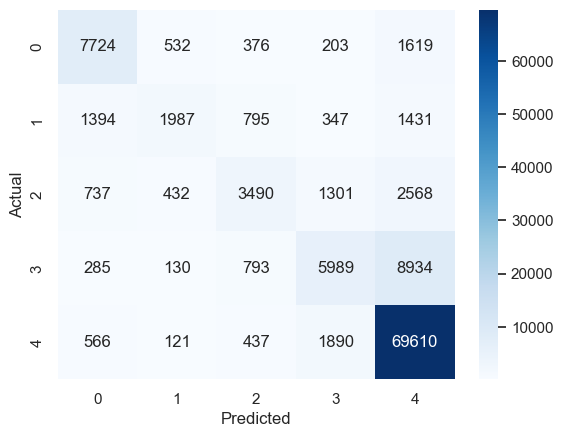

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC Curve

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Binarize the output
y_test_bin = label_binarize(y_test, classes=[1,2,3,4,5])
y_pred_prob = lg.predict_proba(X_test)  # Probabilities

# Compute AUC for each class
auc_scores = {}
for i, cls in enumerate([1,2,3,4,5]):
    auc_scores[cls] = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])

print("AUC scores per class:", auc_scores)

AUC scores per class: {1: 0.9677693618132052, 2: 0.9244727489869621, 3: 0.9055447760948389, 4: 0.8367058855248524, 5: 0.9185633299348386}


# Applying the RandomOverSampler to Handle the Imabalnce

In [30]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape)
print("Resampled training shape:", X_res.shape)

Original training shape: (454763, 50000)
Resampled training shape: (1452490, 50000)


In [31]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, multi_class='multinomial', solver='lbfgs', n_jobs=-1)
log_reg.fit(X_res, y_res)

LogisticRegression(max_iter=2000, multi_class='multinomial', n_jobs=-1)

In [32]:
# Predict on resampled training set
y_pred_train = log_reg.predict(X_res)

# Predict on original test set
y_pred_test = log_reg.predict(X_test)


In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Training Accuracy
print("Training Accuracy:", accuracy_score(y_res, y_pred_train))

# Test Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("\nTraining Classification Report:")
print(classification_report(y_res, y_pred_train))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))


Training Accuracy: 0.8467569484127258
Test Accuracy: 0.7234873472834261

Training Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.91      0.90    290498
           2       0.87      0.90      0.89    290498
           3       0.84      0.85      0.85    290498
           4       0.80      0.77      0.78    290498
           5       0.82      0.81      0.82    290498

    accuracy                           0.85   1452490
   macro avg       0.85      0.85      0.85   1452490
weighted avg       0.85      0.85      0.85   1452490


Test Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.75      0.72     10454
           2       0.42      0.56      0.48      5954
           3       0.44      0.59      0.50      8528
           4       0.44      0.60      0.51     16131
           5       0.92      0.78      0.84     72624

    accuracy                           0.72    1136

# SVM

In [35]:
from sklearn.svm import LinearSVC

linear_svc = LinearSVC(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
linear_svc.fit(X_res, y_res)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

In [36]:
# Predict on resampled training set
y_pred_train_svm = linear_svc.predict(X_res)

# Predict on original test set
y_pred_test_svm = linear_svc.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Training Accuracy
print("Training Accuracy:", accuracy_score(y_res, y_pred_train_svm))

# Test Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_svm))

print("\nTraining Classification Report:")
print(classification_report(y_res, y_pred_train_svm))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test_svm))


Training Accuracy: 0.8836081487652239
Test Accuracy: 0.7128268728395387

Training Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.95      0.94    290498
           2       0.92      0.95      0.93    290498
           3       0.88      0.91      0.90    290498
           4       0.83      0.80      0.81    290498
           5       0.84      0.81      0.83    290498

    accuracy                           0.88   1452490
   macro avg       0.88      0.88      0.88   1452490
weighted avg       0.88      0.88      0.88   1452490


Test Classification Report:
              precision    recall  f1-score   support

           1       0.66      0.74      0.70     10454
           2       0.41      0.55      0.47      5954
           3       0.42      0.57      0.48      8528
           4       0.44      0.58      0.50     16131
           5       0.92      0.77      0.84     72624

    accuracy                           0.71    1136

In [38]:
linear_svc1 = LinearSVC(
    class_weight='balanced',
    max_iter=3000
)

linear_svc1.fit(X_train, y_train)


LinearSVC(class_weight='balanced', max_iter=3000)

In [39]:
# Predict on resampled training set
y_pred_train_sv = linear_svc1.predict(X_train)

# Predict on original test set
y_pred_test_sv = linear_svc1.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Training Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_pred_train_sv))

# Test Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_sv))

print("\nTraining Classification Report:")
print(classification_report(y_train, y_pred_train_sv))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test_sv))


Training Accuracy: 0.8606241053032019
Test Accuracy: 0.7674398149369783

Training Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.91      0.87     41814
           2       0.72      0.83      0.77     23815
           3       0.70      0.79      0.74     34112
           4       0.70      0.66      0.68     64524
           5       0.93      0.91      0.92    290498

    accuracy                           0.86    454763
   macro avg       0.78      0.82      0.80    454763
weighted avg       0.86      0.86      0.86    454763


Test Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.76      0.73     10454
           2       0.46      0.52      0.49      5954
           3       0.48      0.55      0.52      8528
           4       0.54      0.51      0.53     16131
           5       0.90      0.87      0.88     72624

    accuracy                           0.77    1136

# HyperParamter Tuning